# APLICR MODELO POR MES

In [1]:
import pandas as pd #Importar librería pandas
import xgboost as xgb #Importar librería xgboost
import joblib #Importar joblib para cargar modelo/columnas
import os #Importar módulo sistema
import json #Importar módulo json
from datetime import datetime #Importar formateo de fechas

#Cargar configuración desde JSON
with open('config_modelado.json', 'r') as file: #Abrir archivo JSON
    config = json.load(file) #Cargar datos del JSON

extr_anio = config['modelado_params']['anio'] #Definir año a procesar desde JSON
extr_mes = config['modelado_params']['mes'] #Definir mes a procesar desde JSON

#Construir el formato AAMM
str_yymm = datetime(extr_anio, extr_mes, 1).strftime('%y%m') #Formatear fecha

#Rutas dinámicas
FILE_INPUT = f"../ETL/datalake/gold/clean/dataset_master_gold_{str_yymm}.parquet" #Archivo del mes
RUTA_SALIDA_SCORES = f"../ETL/datalake/gold/scored" #Carpeta destino
FILE_OUTPUT = f"{RUTA_SALIDA_SCORES}/predicciones_churn_{str_yymm}.csv" #Archivo final con predicciones

#Rutas del modelo 2025 (Asumiendo que los guardaste desde tu .ipynb)
RUTA_MODELO = "modelo_xgboost_2025.pkl" #Ruta de tu modelo entrenado
RUTA_COLUMNAS = "columnas_entrenamiento_2025.pkl" #Ruta de las columnas exactas

if not os.path.exists(RUTA_SALIDA_SCORES): #Verificar existencia carpeta
    os.makedirs(RUTA_SALIDA_SCORES) #Crear carpeta

def ejecutar_scoring_mensual(): #Definir función principal
    print(f"Iniciando inferencia con XGBoost para el periodo {str_yymm}...") #Imprimir inicio proceso
    
    try: #Bloque prueba lectura
        df = pd.read_parquet(FILE_INPUT) #Cargar archivo parquet del mes
        print("[EXITO] Datos mensuales cargados correctamente.") #Imprimir éxito
    except FileNotFoundError: #Capturar error
        print(f"[ERROR] No se encontró el archivo: {FILE_INPUT}") #Imprimir error
        return #Salir
        
    try: #Iniciar bloque carga
        modelo_xgb = joblib.load(RUTA_MODELO) #Cargar modelo entrenado
        columnas_esperadas = joblib.load(RUTA_COLUMNAS) #Cargar lista de columnas de 2025
        print("[EXITO] Modelo y estructura de columnas cargados.") #Imprimir exito
    except Exception as e: #Capturar error
        print(f"[ERROR] Al cargar el modelo o las columnas: {e}") #Imprimir error
        return #Salir
        
    print("   Aplicando One-Hot Encoding a los datos nuevos...") #Imprimir estado
    vars_categoricas = ['ONT_MODEL', 'ZONA', 'MOTIVO_PEDIDO'] #Definir variables a codificar
    
    df_encoded = pd.get_dummies(df, columns=vars_categoricas) #Aplicar dummies a datos nuevos
    
    print("   Alineando columnas con el modelo de 2025...") #Imprimir estado
    X_nuevos = df_encoded.reindex(columns=columnas_esperadas, fill_value=0) #Alinear y rellenar nulos
    
    print("   Generando predicciones de riesgo...") #Imprimir estado
    probabilidades = modelo_xgb.predict_proba(X_nuevos)[:, 1] #Predecir probabilidad de clase positiva
    predicciones = modelo_xgb.predict(X_nuevos) #Predecir clase final (0 o 1)
    
    print(f"   Guardando resultados en {FILE_OUTPUT}...") #Imprimir estado
    df_resultados = df.copy() #Copiar df original para no perder datos legibles como IDs
    df_resultados['PROBABILIDAD_RIESGO'] = probabilidades #Agregar columna probabilidad
    df_resultados['PREDICCION_ABANDONO'] = predicciones #Agregar columna clase
    
    df_resultados.to_csv(FILE_OUTPUT, index=False, encoding='utf-8-sig') #Exportar a CSV
    print(f"[EXITO] Predicciones generadas y guardadas para {str_yymm}.") #Imprimir exito final

if __name__ == "__main__": #Verificar ejecución directa
    ejecutar_scoring_mensual() #Ejecutar función principal

Iniciando inferencia con XGBoost para el periodo 2602...
[EXITO] Datos mensuales cargados correctamente.
[EXITO] Modelo y estructura de columnas cargados.
   Aplicando One-Hot Encoding a los datos nuevos...
   Alineando columnas con el modelo de 2025...
   Generando predicciones de riesgo...
   Guardando resultados en ../ETL/datalake/gold/scored/predicciones_churn_2602.csv...
[EXITO] Predicciones generadas y guardadas para 2602.


V:\PY\ANACONDA\Lib\pickle.py:1759: UserWarning: [16:58:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\gbm\../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)
V:\PY\ANACONDA\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator GridSearchCV from version 1.8.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## GENERACION SHAP POR MES PARA COMPROBAR CONFIABILIDAD

Iniciando evaluación de confiabilidad y SHAP para 2602...

--- MÉTRICAS DE ESTABILIDAD DEL MODELO ---
Score Promedio Global: 0.0863
Score Máximo Encontrado: 0.7208
Clientes superando umbral 15% riesgo: 11 (2.59% de la base)

   Generando análisis de explicabilidad SHAP...


V:\PY\ANACONDA\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator GridSearchCV from version 1.8.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


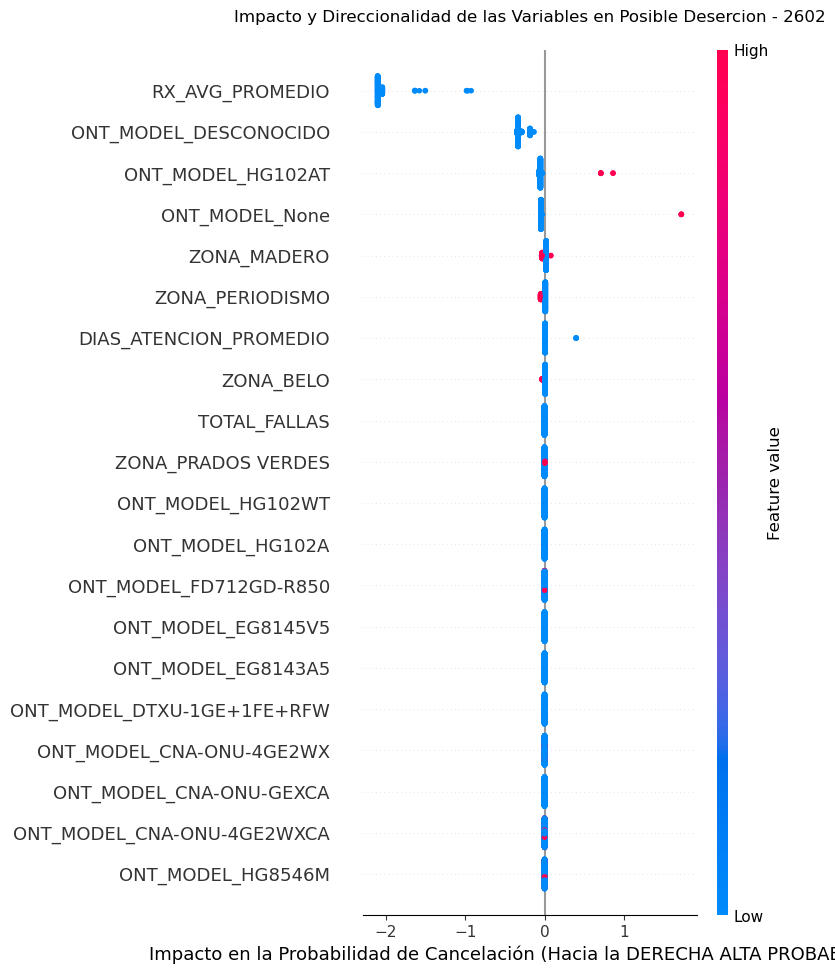

[EXITO] Gráfico SHAP guardado en graficos_modelado_2602/01_shap_summary_2602.png.


In [2]:
import pandas as pd #Importar librería pandas
import xgboost as xgb #Importar librería xgboost
import joblib #Importar joblib para cargar modelo/columnas
import os #Importar módulo sistema
import json #Importar módulo json
import shap #Importar librería shap para explicabilidad
import matplotlib.pyplot as plt #Importar librería pyplot
from datetime import datetime #Importar formateo de fechas

#Cargar configuración desde JSON
with open('config_modelado.json', 'r') as file: #Abrir archivo JSON
    config = json.load(file) #Cargar datos del JSON

extr_anio = config['modelado_params']['anio'] #Definir año a procesar desde JSON
extr_mes = config['modelado_params']['mes'] #Definir mes a procesar desde JSON

#Construir el formato AAMM
str_yymm = datetime(extr_anio, extr_mes, 1).strftime('%y%m') #Formatear fecha

#Rutas dinámicas
FILE_INPUT = f"../ETL/datalake/gold/clean/dataset_master_gold_{str_yymm}.parquet" #Archivo del mes
RUTA_MODELO = "modelo_xgboost_2025.pkl" #Ruta de tu modelo entrenado
RUTA_COLUMNAS = "columnas_entrenamiento_2025.pkl" #Ruta de las columnas exactas
RUTA_SALIDA_GRAFICOS = f"graficos_modelado_{str_yymm}" #Definir carpeta salida de graficos

if not os.path.exists(RUTA_SALIDA_GRAFICOS): #Verificar existencia carpeta
    os.makedirs(RUTA_SALIDA_GRAFICOS) #Crear carpeta graficos

def comprobar_confiabilidad_mensual(): #Definir función principal
    print(f"Iniciando evaluación de confiabilidad y SHAP para {str_yymm}...") #Imprimir inicio proceso
    
    try: #Bloque prueba lectura
        df = pd.read_parquet(FILE_INPUT) #Cargar archivo parquet del mes
        modelo_xgb = joblib.load(RUTA_MODELO) #Cargar modelo entrenado
        if hasattr(modelo_xgb, 'best_estimator_'): #Si es GridSearchCV
            modelo_xgb = modelo_xgb.best_estimator_ #Extraer modelo real
        columnas_esperadas = joblib.load(RUTA_COLUMNAS) #Cargar lista de columnas de 2025
    except Exception as e: #Capturar error
        print(f"[ERROR] Al cargar archivos base: {e}") #Imprimir error
        return #Salir
        
    vars_categoricas = ['ONT_MODEL', 'ZONA', 'MOTIVO_PEDIDO'] #Definir variables a codificar
    df_encoded = pd.get_dummies(df, columns=vars_categoricas) #Aplicar dummies a datos nuevos
    X_nuevos = df_encoded.reindex(columns=columnas_esperadas, fill_value=0) #Alinear y rellenar nulos
    
    probabilidades = modelo_xgb.predict_proba(X_nuevos)[:, 1] #Predecir probabilidad de clase positiva
    df['SCORE_RIESGO'] = probabilidades #Añadir score temporalmente para analisis
    
    print("\n--- MÉTRICAS DE ESTABILIDAD DEL MODELO ---") #Imprimir encabezado metricas
    score_promedio = df['SCORE_RIESGO'].mean() #Calcular media de score
    score_maximo = df['SCORE_RIESGO'].max() #Calcular score maximo
    clientes_riesgo_alto = len(df[df['SCORE_RIESGO'] > 0.15]) #Contar clientes con más de 15% riesgo
    porcentaje_riesgo = (clientes_riesgo_alto / len(df)) * 100 #Calcular porcentaje de riesgo
    
    print(f"Score Promedio Global: {score_promedio:.4f}") #Imprimir media
    print(f"Score Máximo Encontrado: {score_maximo:.4f}") #Imprimir maximo
    print(f"Clientes superando umbral 15% riesgo: {clientes_riesgo_alto} ({porcentaje_riesgo:.2f}% de la base)") #Imprimir poblacion riesgosa
    
    #Advertencia automática si el modelo es demasiado conservador
    if score_maximo < 0.30: #Evaluar si el máximo es muy bajo
        print("[ALERTA] Los scores son inusualmente bajos. Revisa posibles cambios en los datos (Data Drift).") #Imprimir alerta
        
    print("\n   Generando análisis de explicabilidad SHAP...") #Imprimir estado
    
    #Tomar una muestra para no saturar la memoria (calcular SHAP de toda la base toma mucho tiempo)
    tamano_muestra = min(5000, len(X_nuevos)) #Definir maximo 5000 registros
    X_muestra = X_nuevos.sample(n=tamano_muestra, random_state=42) #Muestrear datos
    
    explainer = shap.TreeExplainer(modelo_xgb) #Inicializar explicador de arboles
    shap_values = explainer.shap_values(X_muestra) #Calcular valores shap para la muestra
    
    plt.figure(figsize=(10, 8)) #Configurar tamaño figura
    #Generar grafico summary
    shap.summary_plot(shap_values, X_muestra, show=False, plot_type="dot") #Crear grafico

    ax = plt.gca() #Obtener los ejes actuales del gráfico
    ax.set_xlabel('Impacto en la Probabilidad de Cancelación (Hacia la DERECHA ALTA PROBABILIDAD)') #Personalizar etiqueta inferior
    
    plt.title(f"Impacto y Direccionalidad de las Variables en Posible Desercion - {str_yymm}", pad=20) #Añadir titulo principal
    ruta_grafico_shap = f"{RUTA_SALIDA_GRAFICOS}/01_shap_summary_{str_yymm}.png" #Definir nombre grafico
    
    plt.savefig(ruta_grafico_shap, bbox_inches='tight', dpi=300) #Guardar grafico alta resolucion
    plt.show() #Mostrar grafico consola
    
    print(f"[EXITO] Gráfico SHAP guardado en {ruta_grafico_shap}.") #Imprimir exito final

if __name__ == "__main__": #Verificar ejecución directa
    comprobar_confiabilidad_mensual() #Ejecutar función principal